# Freeze Risk Prediction from Daily Weather Station Data

**Goal:** predict whether a freeze (minimum temperature below 1°C) will happen
within the next 10 days, using lagged daily weather readings as features.

The 10 input files follow the standard ECA&D station variable codes:
`cc` cloud cover, `hu` humidity, `pp` sea-level pressure, `qq` global radiation,
`rr` precipitation, `sd` snow depth, `ss` sunshine duration, `tg` mean temperature,
`tn` minimum temperature, `tx` maximum temperature.

This notebook was reorganized for readability: dead/commented-out experiments were
removed, duplicate cells were merged, and explanatory notes were added throughout.
Logic was **not** changed except where noted (a couple of small, clearly-flagged fixes).

## 1. Imports & config

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from functools import reduce

In [93]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

## 2. Load the raw station files

Each file is one weather variable, all sharing a `date` column.

In [94]:
df_cc = pd.read_csv(config['data']['clean']['file1'], quotechar='"', sep=";")
df_hu = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep=";")
df_pp = pd.read_csv(config['data']['clean']['file3'], quotechar='"', sep=";")
df_qq = pd.read_csv(config['data']['clean']['file4'], quotechar='"', sep=";")
df_rr = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep=";")
df_sd = pd.read_csv(config['data']['clean']['file6'], quotechar='"', sep=";")
df_ss = pd.read_csv(config['data']['clean']['file7'], quotechar='"', sep=";")
df_tg = pd.read_csv(config['data']['clean']['file8'], quotechar='"', sep=";")
df_tn = pd.read_csv(config['data']['clean']['file9'], quotechar='"', sep=";")
df_tx = pd.read_csv(config['data']['clean']['file10'], quotechar='"', sep=";")

Merge all 10 variables into one daily table on `date`.

In [95]:
all_data = reduce(
    lambda left, right: pd.merge(left, right, on=['date'], how='outer'),
    [df_cc, df_hu, df_pp, df_qq, df_rr, df_sd, df_ss, df_tg, df_tn, df_tx]
)
all_data.date = pd.to_datetime(all_data.date, format='%Y-%m-%d')

## 3. Quick exploration on the raw merged data

In [96]:
# plt.figure(figsize=(9, 7))
# sns.heatmap(all_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Correlation between raw weather variables")
# plt.show()

In [97]:
all_data.sd.value_counts()

sd
0.0     17013
1.0        49
2.0        26
4.0        17
3.0        16
5.0         7
6.0         5
8.0         4
7.0         4
11.0        3
10.0        2
12.0        2
9.0         1
22.0        1
20.0        1
16.0        1
18.0        1
15.0        1
13.0        1
Name: count, dtype: int64

In [98]:
all_data["year"] = all_data["date"].dt.year

# how many days per year actually had snow on the ground?
all_data.groupby('year')['sd'].apply(lambda x: (x > 0).sum())
real_temps= all_data['tn']

Decided against creating a model to predict snow, pivoted to icy/very cold temps.

In [99]:
for threshold in [1, 2, 3, 4]:
    print(threshold,
          (all_data['tg'] < threshold).mean())

1 0.0254153308073448
2 0.042378315359953365
3 0.06732730982220927
4 0.09944622559020694


## 4. Feature engineering

In [100]:
# all_data['tn'] = all_data.tn < 1
all_data['tg'] = all_data.tg < 3
all_data["year"] = all_data["date"].dt.year
all_data["day_of_year"] = all_data["date"].dt.dayofyear

# Cyclical encoding of day-of-year, so Dec 31 and Jan 1 are treated as
# neighbours instead of being 364 days apart.
all_data["doy_sin"] = np.sin(2 * np.pi * all_data["day_of_year"] / 365.25)
all_data["doy_cos"] = np.cos(2 * np.pi * all_data["day_of_year"] / 365.25)

# Lag features: only use *past* values to predict the future, never same-day
# or future values, which would leak information the model wouldn't actually
# have at prediction time.
all_data["tn_lag1"] = all_data["tn"].shift(1)
all_data["tn_lag3"] = all_data["tn"].shift(3)
all_data["tn_lag7"] = all_data["tn"].shift(7)

all_data["sd_lag1"] = all_data["sd"].shift(1)
all_data["sd_lag3"] = all_data["sd"].shift(3)
all_data["sd_lag7"] = all_data["sd"].shift(7)
all_data["sd_lag10"] = all_data["sd"].shift(10)

all_data["tx_lag1"] = all_data["tx"].shift(1)
all_data["tg_lag1"] = all_data["tg"].shift(1)

all_data["pp_lag1"] = all_data["pp"].shift(1)
all_data["hu_lag1"] = all_data["hu"].shift(1)
all_data["rr_lag1"] = all_data["rr"].shift(1)
all_data["cc_lag1"] = all_data["cc"].shift(1)

# Drop the first few rows where lag features are undefined (NaN).
all_data = all_data.dropna()

In [101]:
# Post-engineering correlation check, now that lag/cyclical features exist.
all_data.corr()

,date,cc,hu,pp,qq,rr,sd,ss,tg,tn,...,sd_lag1,sd_lag3,sd_lag7,sd_lag10,tx_lag1,tg_lag1,pp_lag1,hu_lag1,rr_lag1,cc_lag1
date,1.000000,-0.098507,-0.085620,-0.009827,-0.164930,0.010738,-0.048220,-0.006393,-0.071735,0.106651,...,-0.048208,-0.048183,-0.048936,-0.052260,0.102989,-0.072114,-0.009684,-0.085898,0.010771,-0.098439
cc,-0.098507,1.000000,0.513794,-0.247959,-0.436846,0.236671,-0.003745,-0.756708,-0.026330,0.030312,...,-0.008985,-0.002526,0.009089,0.023314,-0.234462,0.033348,-0.115717,0.310073,0.153135,0.450352
hu,-0.085620,0.513794,1.000000,-0.234638,-0.671991,0.287788,0.047568,-0.733442,0.139352,-0.330513,...,0.043693,0.044610,0.053617,0.057935,-0.522401,0.162777,-0.166153,0.686235,0.228104,0.303943
pp,-0.009827,-0.247959,-0.234638,1.000000,0.135667,-0.350394,-0.021368,0.227692,0.070412,-0.064779,...,-0.017513,-0.007513,0.000230,-0.000329,0.056930,0.058268,0.821694,-0.197975,-0.396651,-0.214220
qq,-0.164930,-0.436846,-0.671991,0.135667,1.000000,-0.151648,-0.049717,0.777140,-0.205336,0.431997,...,-0.047515,-0.048119,-0.047015,-0.049764,0.616666,-0.211329,0.089225,-0.506355,-0.099514,-0.218309
rr,0.010738,0.236671,0.287788,-0.350394,-0.151648,1.000000,-0.000272,-0.235349,-0.045268,0.029868,...,-0.001679,-0.008824,0.003195,-0.012129,-0.036753,-0.026387,-0.232102,0.099821,0.173229,0.084393
sd,-0.048220,-0.003745,0.047568,-0.021368,-0.049717,-0.000272,1.000000,-0.031527,0.226197,-0.140894,...,0.777360,0.402361,0.076473,0.005969,-0.130060,0.225819,-0.019887,0.042483,0.015136,0.000220
ss,-0.006393,-0.756708,-0.733442,0.227692,0.777140,-0.235349,-0.031527,1.000000,-0.116876,0.229922,...,-0.027848,-0.031760,-0.030494,-0.037687,0.496584,-0.140294,0.126930,-0.449271,-0.131299,-0.321818
tg,-0.071735,-0.026330,0.139352,0.070412,-0.205336,-0.045268,0.226197,-0.116876,1.000000,-0.478658,...,0.210216,0.178254,0.098147,0.087981,-0.453231,0.705094,0.049384,0.122953,-0.056867,-0.050189
tn,0.106651,0.030312,-0.330513,-0.064779,0.431997,0.029868,-0.140894,0.229922,-0.478658,1.000000,...,-0.137109,-0.116454,-0.093906,-0.082601,0.874109,-0.460840,-0.011509,-0.331230,0.038868,0.006662


## 5. Build the modeling table and the target

Select just the features that will actually go into the model, then define
the target: **will a freeze (`tn < 1`) happen at any point in the next 10
days?** This is what `shift(-10)` does -- it looks 10 days *forward*.

In [102]:
df_ice = all_data.copy()

features = [
    'tn_lag1', 'tn_lag3', 'tn_lag7',
    'tg_lag1', 'tx_lag1',
    'cc', 'hu', 'pp', 'rr',
    'doy_sin', 'doy_cos'
]

df_ice = df_ice[features + ['tn', 'year', 'date', 'tg']]

In [103]:
# df_ice['freeze_10d'] = (df_ice['tn'].shift(-10) < 1)
df_ice['cold_10d'] = (df_ice['tg'].shift(-10) < 1)

# The last 10 rows now have no future data to look at, so they're NaN --
# drop them rather than feeding the model a meaningless label.

# df_ice = df_ice.dropna(subset=['freeze_10d'])
df_ice = df_ice.dropna(subset=['cold_10d'])

## 6. Train/test split -- chronological, not random

Splitting by year (train on ≤2021, test on >2021) instead of a random split
keeps the time order intact and avoids leaking future information into
training, which a random split would do on time-series data like this.

In [104]:
train = df_ice[df_ice.year <= 2021]
test  = df_ice[df_ice.year > 2021]

# y_train = train['freeze_10d']
# y_test  = test['freeze_10d']
y_train = train['cold_10d']
y_test  = test['cold_10d']

X_train = train[features]
X_test  = test[features]

**Class balance check** -- how rare is a 'freeze in the next 10 days' event, in the raw data and in each split?

In [105]:
print("Overall freeze-day rate (tn):")
print(all_data['tn'].value_counts(normalize=True))

print("\ny_train class counts:")
print(y_train.value_counts())

print("\ny_test class counts:")
print(y_test.value_counts())

Overall freeze-day rate (tn):
tn
13.000000    0.007524
7.500000     0.007232
10.000000    0.007174
11.200000    0.006999
9.500000     0.006999
               ...   
3.833333     0.000058
2.866667     0.000058
10.750000    0.000058
7.533333     0.000058
4.166667     0.000058
Name: proportion, Length: 621, dtype: float64

y_train class counts:
cold_10d
True     14603
False     1082
Name: count, dtype: int64

y_test class counts:
cold_10d
True     1393
False      67
Name: count, dtype: int64


## 7. Scaling

In [106]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

print(f"Train shape: {X_train.shape}")

normalizer = MinMaxScaler()
normalizer.fit(X_train)
X_train_norm = pd.DataFrame(normalizer.transform(X_train), columns=X_train.columns)
X_test_norm  = pd.DataFrame(normalizer.transform(X_test),  columns=X_test.columns)

Train shape: (15685, 11)


In [107]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# forest = RandomForestClassifier(n_estimators=100, max_depth=20)
# forest.fit(X_train_norm, y_train)
# y_pred_test_rf = forest.predict(X_test_norm)

# print(f"Accuracy: {forest.score(X_test_norm, y_test):.2f}")

In [108]:
# print(classification_report(y_test, y_pred_test_rf))

In [109]:
# pd.Series(
#     forest.feature_importances_,
#     index=X_train.columns
# ).sort_values(ascending=False)

## 8. 10 day model: class-balanced Random Forest

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

df = all_data.copy()
# df = df[features + ['tn', 'year', 'date']]
df = df[features + ['tg', 'year', 'date']]

# df['y'] = (df['tn'].shift(-10) < 1)
df['y'] = (df['tg'].shift(-10) < 1)
df = df.dropna(subset=['y'])

train = df[(df.year <= 2021) & (df.year >= 1991)]
test  = df[df.year > 2021]

y_train = train['y']
y_test  = test['y']
X_train = train[features]
X_test  = test[features]

model_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.21      0.70      0.33        67
        True       0.98      0.87      0.93      1393

    accuracy                           0.87      1460
   macro avg       0.60      0.79      0.63      1460
weighted avg       0.95      0.87      0.90      1460



In [181]:
print(f"Accuracy: {model_balanced.score(X_test, y_test):.2f}")

Accuracy: 0.87


In [182]:
pd.Series(
    model_balanced.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

doy_cos    0.340742
tx_lag1    0.194917
tn_lag1    0.085237
tn_lag7    0.084301
tn_lag3    0.083619
doy_sin    0.081266
pp         0.042909
hu         0.042452
rr         0.019499
cc         0.016919
tg_lag1    0.008139
dtype: float64

In [183]:
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [10, 50, 100, 500]
# Maximum number of levels in tree
max_depth = [50, 100, 200,500]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
                              }

In [184]:
rf = RandomForestClassifier(class_weight="balanced",random_state=42)

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 10, cv = 3,random_state=42)
# Fit the random search model
gs = rf_random.fit(X_train, y_train)

In [185]:
best_model = gs.best_estimator_
y_pred_train_df = best_model.predict(X_train)
y_pred_test_df  = best_model.predict(X_test)

In [186]:
print(classification_report(y_test, y_pred_test_df))

              precision    recall  f1-score   support

       False       0.11      0.07      0.09        67
        True       0.96      0.97      0.96      1393

    accuracy                           0.93      1460
   macro avg       0.53      0.52      0.53      1460
weighted avg       0.92      0.93      0.92      1460



In [187]:
pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

doy_cos    0.284944
tx_lag1    0.187871
tn_lag1    0.102503
tn_lag3    0.093877
tn_lag7    0.083688
doy_sin    0.080837
pp         0.055733
hu         0.051535
rr         0.027238
cc         0.024670
tg_lag1    0.007103
dtype: float64

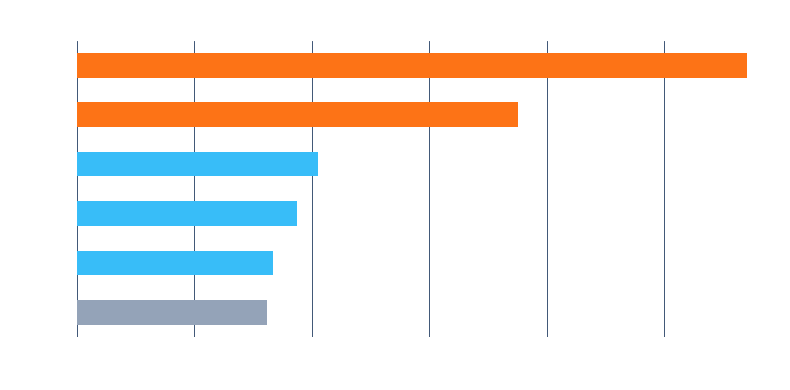

In [188]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(6)

colors = ["#fd7316" if i >= 4 else "#94a3b8" if "doy" in f else "#38bdf8"
          for i, f in enumerate(importances.index)]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

importances.plot.barh(ax=ax, color=colors)

ax.set_title("Feature Importances — Tuned Random Forest", color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Importance", color="white")
ax.tick_params(colors="white", axis="both")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color="#1e3a5f", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("feature_importance_10.png", transparent=True, dpi=150, bbox_inches="tight")
plt.show()

In [189]:
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over.fit_resample(X_train,y_train)

In [190]:
rs = rf_random.fit(X_train_over, y_train_over)
best_model = rs.best_estimator_
y_pred_train_df = best_model.predict(X_train_over)
y_pred_test_df  = best_model.predict(X_test)

In [191]:
print(classification_report(y_test, y_pred_test_df))

              precision    recall  f1-score   support

       False       0.14      0.03      0.05        67
        True       0.96      0.99      0.97      1393

    accuracy                           0.95      1460
   macro avg       0.55      0.51      0.51      1460
weighted avg       0.92      0.95      0.93      1460



## 8. 5 day model: class-balanced Random Forest

In [192]:
df = all_data.copy()
# df = df[features + ['tn', 'year', 'date']]
df = df[features + ['tg', 'year', 'date']]

# df['y'] = (df['tn'].shift(-5) < 1)
df['y'] = (df['tg'].shift(-5) < 1)
df = df.dropna(subset=['y'])

train = df[(df.year <= 2021) & (df.year >= 1991)]
test  = df[df.year > 2021]

y_train = train['y']
y_test  = test['y']
X_train = train[features]
X_test  = test[features]

model_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.25      0.63      0.36        63
        True       0.98      0.92      0.95      1397

    accuracy                           0.90      1460
   macro avg       0.62      0.78      0.65      1460
weighted avg       0.95      0.90      0.92      1460



In [193]:
print(f"Accuracy: {model_balanced.score(X_test, y_test):.2f}")

Accuracy: 0.90


In [194]:
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [10, 50, 100, 500]
# Maximum number of levels in tree
max_depth = [50, 100, 200,500]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_depth': max_depth,
                              }

In [195]:
rf = RandomForestClassifier(class_weight="balanced",random_state=42)

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 10, cv = 3,random_state=42)
# Fit the random search model
gs = rf_random.fit(X_train, y_train)

In [196]:
best_model = gs.best_estimator_
y_pred_train_df = best_model.predict(X_train)
y_pred_test_df  = best_model.predict(X_test)

In [197]:
pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

doy_cos    0.262858
tx_lag1    0.199557
tn_lag1    0.107922
tn_lag7    0.090878
tn_lag3    0.089897
doy_sin    0.084856
pp         0.052688
hu         0.044436
rr         0.029417
cc         0.024974
tg_lag1    0.012517
dtype: float64

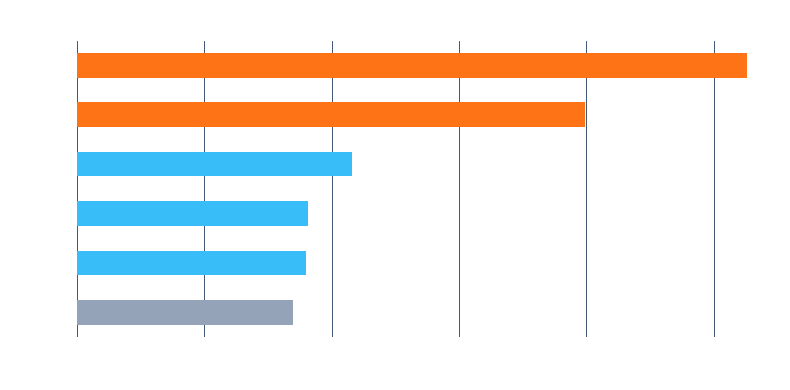

In [198]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(6)

colors = ["#fd7316" if i >= 4 else "#94a3b8" if "doy" in f else "#38bdf8"
          for i, f in enumerate(importances.index)]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

importances.plot.barh(ax=ax, color=colors)

ax.set_title("Feature Importances — Tuned Random Forest", color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Importance", color="white")
ax.tick_params(colors="white", axis="both")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(True, color="#1e3a5f", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("feature_importance_5.png", transparent=True, dpi=150, bbox_inches="tight")
plt.show()

In [199]:
print(classification_report(y_test, y_pred_test_df))

              precision    recall  f1-score   support

       False       0.26      0.22      0.24        63
        True       0.97      0.97      0.97      1397

    accuracy                           0.94      1460
   macro avg       0.61      0.60      0.60      1460
weighted avg       0.93      0.94      0.94      1460



In [200]:
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under.fit_resample(X_train,y_train)

In [201]:
gs = rf_random.fit(X_train_under, y_train_under)
best_model = gs.best_estimator_
y_pred_train_df = best_model.predict(X_train_under)
y_pred_test_df  = best_model.predict(X_test)

In [202]:
print(classification_report(y_test, y_pred_test_df))

              precision    recall  f1-score   support

       False       0.17      0.92      0.29        63
        True       1.00      0.80      0.89      1397

    accuracy                           0.81      1460
   macro avg       0.59      0.86      0.59      1460
weighted avg       0.96      0.81      0.86      1460



In [203]:
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over.fit_resample(X_train,y_train)

In [204]:
gs = rf_random.fit(X_train_over, y_train_over)
best_model = gs.best_estimator_
y_pred_train_df = best_model.predict(X_train_over)
y_pred_test_df  = best_model.predict(X_test)

In [205]:
print(classification_report(y_test, y_pred_test_df))

              precision    recall  f1-score   support

       False       0.14      0.05      0.07        63
        True       0.96      0.99      0.97      1397

    accuracy                           0.95      1460
   macro avg       0.55      0.52      0.52      1460
weighted avg       0.92      0.95      0.93      1460



## Summary

Two Random Forest classifiers predict whether a freeze will occur within the
next 10 or 5 days, respectively, using lagged temperature/humidity/pressure/precipitation
features plus a cyclical day-of-year encoding, split chronologically into a
pre-2022 training set and a post-2021 test set:

- **Final** (`model_balanced`): 200 trees, max depth 15, `class_weight="balanced"`,
  trained on unscaled features, with a fixed random seed for reproducibility.